In [2]:
### To produce the combined plot in the section.

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

from gamma.cutcount import (
    CeAcCutCountConfig,
    EnergyWindowSpec,
    estimate_ceac_mixture_cutcount,
    estimate_single_isotope_cutcount
)
from gamma.efficiency import EfficiencyFitSpec, fit_efficiency_model
from gamma.artifacts import ArtifactStore


In [4]:
### For Viz
#Default plot parameters
pltmap = plt.get_cmap("tab10")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [5]:
store = ArtifactStore(repo_root / "artifacts")

In [6]:
cfg = CeAcCutCountConfig(
    ce_window=EnergyWindowSpec(center_keV=1022.0, resolution_pct_fwhm=8.0, nsigma=2.0),
    ac_window=EnergyWindowSpec(center_keV=440.0,  resolution_pct_fwhm=8.0, nsigma=2.0),  # or 218.0
)

In [7]:
exp_mix = "ANIL_MIX_SD__agg__bkgsub"
exp_ce  = "ANIL_CE_SD__agg__bkgsub"
exp_ac  = "ANIL_AC_SD__agg__bkgsub"
cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"

mix_cal = store.load_calibration(exp_mix, cal_tag)
ce_cal  = store.load_calibration(exp_ce,  cal_tag)
ac_cal  = store.load_calibration(exp_ac,  cal_tag)

In [8]:
mix_label = mix_cal.labels[4]
ce_template_label = ce_cal.labels[1]

print(f"Mix label: {mix_label}")
print(f"Ce template label: {ce_template_label}")

mix_spec = mix_cal.calibrated[mix_label]
ce_tpl   = ce_cal.calibrated[ce_template_label]

Mix label: 3.906:3.906
Ce template label: 1000


In [9]:
truth_ce = store.load_ground_truth(exp_ce)["labels"]
truth_ac = store.load_ground_truth(exp_ac)["labels"]

# label -> activity_Bq
ce_truth_bq = {
    lbl: float(truth_ce[lbl]["ce134"]["value"])
    for lbl in truth_ce
    if ("ce134" in truth_ce[lbl]) and (truth_ce[lbl]["ce134"].get("value") is not None)
}

ac_truth_bq = {
    lbl: float(truth_ac[lbl]["ac225"]["value"])
    for lbl in truth_ac
    if ("ac225" in truth_ac[lbl]) and (truth_ac[lbl]["ac225"].get("value") is not None)
}

print("Ce truth entries:", len(ce_truth_bq))
print("Ac truth entries:", len(ac_truth_bq))

Ce truth entries: 10
Ac truth entries: 10


In [10]:
ce_emin, ce_emax = cfg.ce_window.bounds()
ac_emin, ac_emax = cfg.ac_window.bounds()

ce_fit = EfficiencyFitSpec(
    name="ce134_win1022_counts60s_v2",
    label_to_activity=ce_truth_bq,
    model_type="nonparalyzable",          # or "nonparalyzable"
    emin_keV=float(ce_emin),
    emax_keV=float(ce_emax),
    livetime_s=60.0,
    rate_units="counts",
)

ac_fit = EfficiencyFitSpec(
    name="ac225_win_counts60s_v2",  # rename if you want "win218" vs "win440"
    label_to_activity=ac_truth_bq,
    model_type="nonparalyzable",            # or "nonparalyzable"
    emin_keV=float(ac_emin),
    emax_keV=float(ac_emax),
    livetime_s=60.0,
    rate_units="counts",
)

ce_eff_model = fit_efficiency_model(ce_cal, ce_fit)
ac_eff_model = fit_efficiency_model(ac_cal, ac_fit)

print("Ce model:", ce_eff_model.name, ce_eff_model.model_type, ce_eff_model.params)
print("Ac model:", ac_eff_model.name, ac_eff_model.model_type, ac_eff_model.params)


Ce model: ce134_win1022_counts60s_v2 nonparalyzable {'a': 2.1722779095662186, 'b': 3.480697170073751e-06}
Ac model: ac225_win_counts60s_v2 nonparalyzable {'a': 3.4677227169834506, 'b': 6.991402446751088e-08}


In [11]:
x_keV = np.asarray(mix_spec["bin_centers_kev"], dtype=float)
y_mix = np.asarray(mix_spec["counts_vals"], dtype=float)
y_ce_template = np.asarray(ce_tpl["counts_vals"], dtype=float)

# est, extra, fit_arrays = estimate_ceac_mixture_cutcount(
#     experiment_id=exp_mix,
#     label=mix_label,
#     x_keV=x_keV,
#     y_mix=y_mix,
#     y_ce_template=y_ce_template,
#     ce_eff_model=ce_eff_model,
#     ac_eff_model=ac_eff_model,
#     config=cfg,
#     ce_template_label=ce_template_label,
# )

x_ce_tpl = np.asarray(ce_tpl["bin_centers_kev"], dtype=float)

est, extra, fit_arrays = estimate_ceac_mixture_cutcount(
    experiment_id=exp_mix,
    label=mix_label,
    x_keV=x_keV,
    y_mix=y_mix,
    y_ce_template=y_ce_template,
    x_ce_template_keV=x_ce_tpl,   # <-- new
    ce_eff_model=ce_eff_model,
    ac_eff_model=ac_eff_model,
    config=cfg,
    ce_template_label=ce_template_label,
)

# print("Estimated activities (Bq):", est.activities_bq)
# print("Estimated uncertainties (Bq):", est.uncertainties_bq)
# print("Scale Ce template:", extra["scale_ce_template"])

# plt.figure()
# plt.step()
# plt.step(fit_arrays["x_keV"], fit_arrays["y_mix"], where="mid", label="Mixture", alpha=0.7)
# plt.step(fit_arrays["x_keV"], fit_arrays["y_ce_scaled"], where="mid", label="Scaled Ce template", alpha=0.7)
# plt.step(fit_arrays["x_keV"], fit_arrays["y_residual"], where="mid", label="Residual", alpha=0.9)
# plt.yscale("log")
# plt.xlim(*cfg.roi_keV)
# plt.legend()
# plt.title("Cut-and-count decomposition (Ce→subtract→Ac)")
# plt.show()

# build a richer run_config (adds provenance) before making run_id
run_config = dict(est.diagnostics.get("run_config", {}))
run_config["templates"] = {
    "ce134": {"experiment_id": exp_ce, "cal_tag": cal_tag, "label": ce_template_label}
}
run_config["eff_models"] = {
    "ce": {"name": ce_eff_model.name, "type": ce_eff_model.model_type},
    "ac": {"name": ac_eff_model.name, "type": ac_eff_model.model_type},
}
# store it back into the estimate for provenance
est.diagnostics["run_config"] = run_config

run_id = ArtifactStore.make_run_id(run_config, prefix=cfg.method_tag)

existing = set(store.list_cutcount_runs(exp_mix, mix_label))
if run_id in existing:
    print('exists, as expected, not saved')
else:
    # Save JSON + arrays (arrays optional; requires the artifacts.py patch)
    # store.save_cutcount_estimate(
    #     est,
    #     run_id=run_id,
    #     fit_arrays={
    #         "x_keV": fit_arrays["x_keV"],
    #         "y_mix": fit_arrays["y_mix"],
    #         "y_ce_scaled": fit_arrays["y_ce_scaled"],
    #         "y_residual": fit_arrays["y_residual"],
    #     },
    # )

    # display(fit_arrays)

    store.save_cutcount_estimate(
        est,
        run_id=run_id,
        fit_arrays={
            "x_keV": fit_arrays["x_keV"],
            "y_mix": fit_arrays["y_mix"],

            # native Ce template grid
            # "x_ce_template_keV": fit_arrays["x_ce_template_keV"],
            # "y_ce_template_native": fit_arrays["y_ce_template_native"],

            # resampled template used in subtraction
            "y_template_ce": fit_arrays["y_template_ce"],
            "y_scaled_template_ce": fit_arrays["y_scaled_template_ce"],

            "y_residual": fit_arrays["y_residual"],
        },
    )


    print("Saved run_id:", run_id)

exists, as expected, not saved


In [12]:
from pathlib import Path
import matplotlib.pyplot as plt
import sys

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))

from gamma.artifacts import ArtifactStore
from gamma.mle import fit_mle_poisson, to_mle_estimate

In [13]:
### For Viz
#Default plot parameters
pltmap = plt.get_cmap("tab10")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = ':'
plt.rcParams['grid.alpha'] = 0.5
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [14]:
# store = ArtifactStore("../artifacts")   # or wherever your root is

store = ArtifactStore(repo_root / "artifacts")

Keeping track of labels defined in other notebook:

"Experiments"
- `ANIL_MIX_SD__agg__bkgsub`
- `ANIL_AC_SD__agg__bkgsub`
- `WENJO_CE_SD__agg__bkgsub__nobkgrows`
- `ANIL_CE_SD__agg__bkgsub`

"Cal tag"

- `'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1'` Anil Ce-134, Wenjo Ce-134, Anil Ac-225 and Anil Mix all had the same cal_tag

Efficiency curve

- `"ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ce-134
- `"ce134_wenjoSD_resp_200-1250keV_cpm_nCi_np_v1"` just Wenjo Ce-134
- `"ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"` just Anil Ac-225
- `"ce134_resp_200-1250keV_cpm_nCi_np_v1"` Wenjo + Anil Ce-134

# 1. Load Experiments and Calibrations

In [15]:
anil_ce_exp_id  = "ANIL_CE_SD__agg__bkgsub"
anil_ac_exp_id  = "ANIL_AC_SD__agg__bkgsub"
anil_mix_exp_id = "ANIL_MIX_SD__agg__bkgsub"

cal_tag = "peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1"

anil_ce_cal  = store.load_calibration(anil_ce_exp_id, cal_tag)
anil_ac_cal  = store.load_calibration(anil_ac_exp_id, cal_tag)
anil_mix_cal = store.load_calibration(anil_mix_exp_id, cal_tag)

# 2. Choose Templates for MLE

In [16]:
ce_template_label = anil_ce_cal.labels[1]
print(f'Ce template: {ce_template_label} nCi')
ac_template_label = anil_ac_cal.labels[1]
print(f'Ac template: {ac_template_label} nCi')

ce_template = anil_ce_cal.calibrated[ce_template_label]
ac_template = anil_ac_cal.calibrated[ac_template_label]

Ce template: 1000 nCi
Ac template: 1000 nCi


# 3. Load Efficiency Models (Activity-to-Detector Response)

In [17]:
ce_eff_name = "ce134_anilSD_resp_200-1250keV_cpm_nCi_np_v1"
ac_eff_name = "ac225_anilSD_resp_200-1250keV_cpm_nCi_np_v1"

ce_eff = store.load_efficiency_model(ce_eff_name)
ac_eff = store.load_efficiency_model(ac_eff_name)

# 4. Load Input Spectrum
- Load mixed spectrum on which we will perform MLE on

In [18]:
mix_label = anil_mix_cal.labels[4]
print(f'Mixed spectrum input (ce:ac): {mix_label} nCi')
mix_spec = anil_mix_cal.calibrated[mix_label]

Mixed spectrum input (ce:ac): 3.906:3.906 nCi


# 5. Run MLE
- Define MLE config to track provenance and MLE parameters
- Run MLE with `fit_mle_poisson`
- Return estimate with `to_mle_estimate`

In [19]:
# ---- Run config (THIS is now the stable provenance) ----
mle_config = {
    "method": "poisson_mle_v1",
    "roi_keV": [200, 1250],
    "activity_units": "nci",
    "templates": {
        "ce134": {"experiment_id": anil_ce_exp_id, "cal_tag": cal_tag, "label": ce_template_label},
        "ac225": {"experiment_id": anil_ac_exp_id, "cal_tag": cal_tag, "label": ac_template_label},
    },
    "eff_models": {
        "ce134": ce_eff_name,
        "ac225": ac_eff_name,
    },
    # optional: include fit settings if they matter
    "fit_settings": {"method": "L-BFGS-B"},
}

run_id = ArtifactStore.make_run_id(mle_config, prefix="mle_poisson_v1")

fit2 = fit_mle_poisson(
    mix_spec,
    templates={"ce134": ce_template, "ac225": ac_template},
    eff_models={"ce134": ce_eff, "ac225": ac_eff},
    emin_keV=200, emax_keV=1250,
    activity_units="nci",
)

est2 = to_mle_estimate(
    fit2,
    experiment_id=anil_mix_exp_id,
    label=mix_label,
    activity_units="nci",
    run_config=mle_config,
)

c:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\12-23-2025\gamma_pipeline\gamma\mle.py:199: RuntimeWarning: divide by zero encountered in log
  term = mu - y + np.where(y > 0, y * np.log(y / mu), 0.0)
c:\Users\pomar\OneDrive\Desktop\Hidex_AcCe_July2_Wenjo_Project\12-23-2025\gamma_pipeline\gamma\mle.py:199: RuntimeWarning: invalid value encountered in multiply
  term = mu - y + np.where(y > 0, y * np.log(y / mu), 0.0)


# 6. Visualize MLE Result

In [20]:
mix_spec

{'counts_vals': array([12.5,  6. ,  0. , ...,  0. ,  0. ,  0. ]),
 'bin_centers_kev': array([   3.12800688,    4.1261477 ,    5.12423876, ..., 1940.33460399,
        1941.230992  , 1942.12733025]),
 'meta': {'kind': 'Spectrum',
  'livetime': 60.0,
  'schema': 'bq_v1',
  'x_attr': 'bin_centers_kev',
  'x_units': 'keV',
  'y_attr': 'counts_vals'}}

In [21]:
fit2.components_hat

{'ac225': array([7.75860397, 8.35659213, 9.11037391, ..., 0.02241318, 0.02349185,
        0.02280036]),
 'ce134': array([4.71210235, 4.64581224, 4.6036278 , ..., 1.08258101, 1.07790629,
        1.06465337])}

In [22]:
est2

MLEEstimate(experiment_id='ANIL_MIX_SD__agg__bkgsub', label='3.906:3.906', activities_bq={'ac225': 146.9568540027306, 'ce134': 155.8874553879625}, uncertainties_bq={'ac225': 3.6112248589538654, 'ce134': 2.460605081171403}, diagnostics={'fit': {'emin_keV': 200.0, 'emax_keV': 1250.0, 'activity_units': 'nci', 'method': 'L-BFGS-B', 'success': True, 'status': 0, 'fun_nll2': 287.6157142253695, 'nit': 11, 'message': 'CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL', 'x0': [1.0, 1.0], 'bounds': [(0.0, None), (0.0, None)]}, 'fit_meta': {'nll2': 287.6157142253695, 'labels': ['ac225', 'ce134'], 'success': True, 'message': 'CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL', 'nit': 11}, 'run_config': {'method': 'poisson_mle_v1', 'roi_keV': [200, 1250], 'activity_units': 'nci', 'templates': {'ce134': {'experiment_id': 'ANIL_CE_SD__agg__bkgsub', 'cal_tag': 'peakfit_v1_xmin200_snr1.2_tol75_fitfit_ord1', 'label': '1000'}, 'ac225': {'experiment_id': 'ANIL_AC_SD__agg__bkgsub', 'cal_tag': 'peakfit_v1_xmi

K=2 activities: {'ac225': 3.971806864938665, 'ce134': 4.213174469944932}
K=2 sigmas: {'ac225': 0.09760067186361798, 'ce134': 0.06650284003165954}


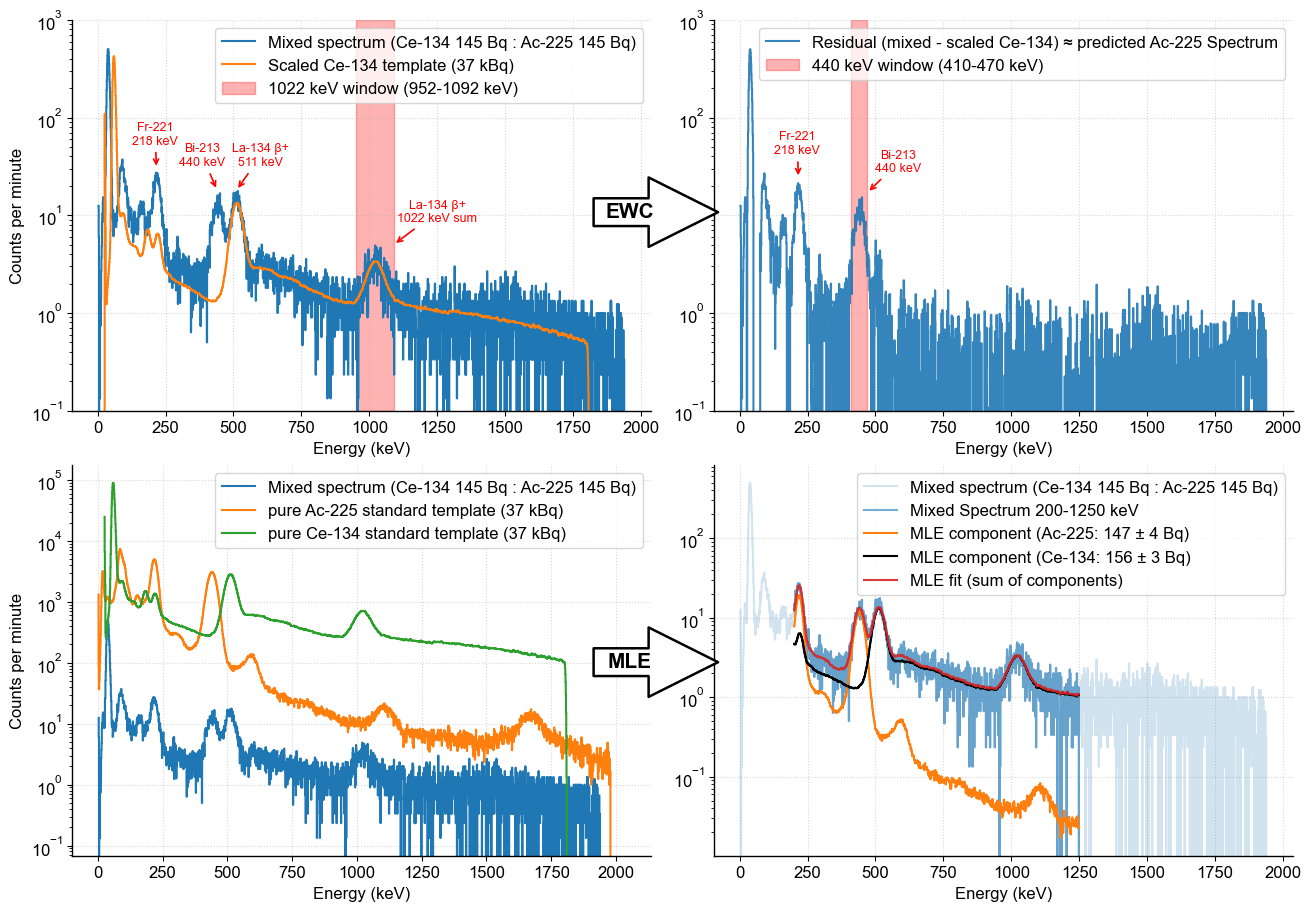

In [104]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import FancyArrowPatch

# Example: load 4 already-generated images
# img1 = mpimg.imread("panel1.png")
# img2 = mpimg.imread("panel2.png")
# img3 = mpimg.imread("panel3.png")
# img4 = mpimg.imread("panel4.png")

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

# place images
# axes[0, 0].imshow(img1)
# axes[0, 1].imshow(img2)
# axes[1, 0].imshow(img3)
# axes[1, 1].imshow(img4)



# plt.figure()

# plt.step(mix_spec['bin_centers_kev'], mix_spec['counts_vals'])


axes[0, 0].step(fit_arrays["x_keV"], fit_arrays["y_mix"], where="mid", label="Mixed spectrum (Ce-134 145 Bq : Ac-225 145 Bq)", alpha=1)
axes[0, 0].step(fit_arrays["x_keV"], fit_arrays["y_ce_scaled"], where="mid", label="Scaled Ce-134 template (37 kBq)", alpha= 1, color='C1')

axes[0, 0].axvspan(952.5647558386412, 1091.4352441613587, color="red", alpha=0.3, label="1022 keV window (952-1092 keV)")

# plt.step(fit_arrays["x_keV"], fit_arrays["y_template_ce"], where="mid", label="og template WRONG x axis", alpha=0.7)
# plt.step(fit_arrays["x_ce_template_keV"], fit_arrays["y_template_ce"], where="mid", label="og template RIGHT x axis", alpha=0.7)

axes[0, 0].set_yscale("log")
# plt.xlim(200, 1250)
# plt.axvline(511)

axes[0, 0].set_ylabel('Counts per minute')
axes[0, 0].set_xlabel('Energy (keV)')
axes[0, 0].legend()
axes[0, 0].set_ylim(0.1,1000)
# plt.xlim(100,2000)
# plt.title("Cut-and-count decomposition (Ce→subtract→Ac)")
# axes[0, 0].show()

# ---------------------------------------------------------------------------------

# plt.figure()

# plt.step(mix_spec['bin_centers_kev'], mix_spec['counts_vals'])


axes[0, 1].step(fit_arrays["x_keV"], fit_arrays["y_residual"], where="mid", label="Residual (mixed - scaled Ce-134) ≈ predicted Ac-225 Spectrum", color='C0', alpha=0.9)
axes[0, 1].axvspan(410.10615711252655, 469.89384288747345, color="red", alpha=0.3, label="440 keV window (410-470 keV)")

# plt.step(fit_arrays["x_keV"], fit_arrays["y_mix"], where="mid", label="Mixed spectrum (Ce-134 3.906 nCi : Ac-225 3.906 nCi)", alpha=1)
# plt.step(fit_arrays["x_keV"], fit_arrays["y_ce_scaled"], where="mid", label="Scaled Ce-134 template (1000 nCi)", alpha= 1, color='C2')
# plt.step(fit_arrays["x_keV"], fit_arrays["y_residual"], where="mid", label="Residual (mixed - scaled Ce) ≈ predicted Ac-225 Spectrum", color='C1', alpha=0.9)

# plt.step(fit_arrays["x_keV"], fit_arrays["y_template_ce"], where="mid", label="og template WRONG x axis", alpha=0.7)
# plt.step(fit_arrays["x_ce_template_keV"], fit_arrays["y_template_ce"], where="mid", label="og template RIGHT x axis", alpha=0.7)

axes[0, 1].set_yscale("log")
# plt.xlim(200, 1250)
# plt.axvline(511)

# axes[0, 1].set_ylabel('Counts per minute')
axes[0, 1].set_xlabel('Energy (keV)')
axes[0, 1].legend()
axes[0, 1].set_ylim(0.1,1000)
# plt.xlim(100,2000)
# plt.title("Cut-and-count decomposition (Ce→subtract→Ac)")
# plt.show()


# ---------------------------------------------------------------------------------

axes[1, 0].step(mix_spec['bin_centers_kev'], mix_spec['counts_vals'], label="Mixed spectrum (Ce-134 145 Bq : Ac-225 145 Bq)")
axes[1, 0].step(ac_template['bin_centers_kev'], ac_template['counts_vals'], label="pure Ac-225 standard template (37 kBq)")
axes[1, 0].step(ce_template['bin_centers_kev'], ce_template['counts_vals'], label="pure Ce-134 standard template (37 kBq)")

axes[1, 0].set_yscale("log")
axes[1, 0].set_ylabel('Counts per minute')
axes[1, 0].set_xlabel('Energy (keV)')

axes[1, 0].legend()
# plt.show()

# ---------------------------------------------------------------------------------

# plt.figure(figsize=(8,6))
axes[1, 1].step(mix_spec['bin_centers_kev'], mix_spec['counts_vals'], label="Mixed spectrum (Ce-134 145 Bq : Ac-225 145 Bq)", alpha=0.2)

axes[1, 1].step(fit2.x_keV, fit2.y_obs, where="mid", label="Mixed Spectrum 200-1250 keV", alpha=0.6, color='C0')

comp = fit2.components_hat['ac225']
k = 'Ac-225'
axes[1, 1].step(fit2.x_keV, comp, where="mid", label=f"MLE component ({k}: 147 ± 4 Bq)", alpha=1)

comp = fit2.components_hat['ce134']
k = 'Ce-134'
axes[1, 1].step(fit2.x_keV, comp, where="mid", label=f"MLE component ({k}: 156 ± 3 Bq)", color='black')

axes[1, 1].step(fit2.x_keV, fit2.y_hat, where="mid", label="MLE fit (sum of components)", alpha=0.9, color ='C3') #or should the label say "best linear combination of the standard priors guess of the mixed spectrum" or 
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("Energy (keV)")
# axes[1, 1].set_ylabel("Counts per minute")
axes[1, 1].legend()
# plt.title(f"K=2 MLE on {mix_label}")
# plt.show()

print("K=2 activities:", fit2.activities)
print("K=2 sigmas:", fit2.sigma_activities)


# hide axes
# for ax in axes.flat:
#     ax.axis("off")

# -------------------------
# Add right-pointing arrow for top row: EWC
# -------------------------
arrow_top = FancyArrowPatch(
    (0.45, 0.77),   # moved right
    (0.55, 0.77),   # moved right + slightly longer
    transform=fig.transFigure,
    arrowstyle="simple",
    mutation_scale=100,   # bigger = thicker / chunkier arrow
    linewidth=1.8,
    facecolor="white",   # white interior
    edgecolor="black"
)
fig.add_artist(arrow_top)

fig.text(
    0.48, 0.77,     # centered inside new arrow position
    "EWC",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)

# -------------------------
# Add right-pointing arrow for bottom row: MLE
# -------------------------
arrow_bottom = FancyArrowPatch(
    (0.45, 0.27),
    (0.55, 0.27),
    transform=fig.transFigure,
    arrowstyle="simple",
    mutation_scale=100,
    linewidth=1.8,
    facecolor="white",
    edgecolor="black"
)
fig.add_artist(arrow_bottom)

fig.text(
    0.48, 0.27,
    "MLE",
    ha="center",
    va="center",
    fontsize=15,
    fontweight="bold"
)



# -----------------------------------------
# RED PHOTOPEAK LABELS WITH VERTICAL ARROWS
# -----------------------------------------



axes[0, 0].annotate(
    "Fr-221\n218 keV",
    xy=(216, 30),          # arrow tip = peak location
    xytext=(212, 50),     # text position above peak
    ha="center",
    va="bottom",
    color="red",
    fontsize=9,
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.2
    )
)


axes[0, 0].annotate(
    "Bi-213\n440 keV",
    xy=(440, 18),          # arrow tip = peak location
    xytext=(385, 30),     # text position above peak
    ha="center",
    va="bottom",
    color="red",
    fontsize=9,
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.2
    )
)

axes[0, 0].annotate(
    "La-134 β+\n511 keV",
    xy=(511, 18),          # arrow tip = peak location
    xytext=(600, 30),     # text position above peak
    ha="center",
    va="bottom",
    color="red",
    fontsize=9,
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.2
    )
)

axes[0, 0].annotate(
    "La-134 β+\n1022 keV sum",
    xy=(1090, 5),          # arrow tip = peak location
    xytext=(1250, 8),     # text position above peak
    ha="center",
    va="bottom",
    color="red",
    fontsize=9,
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.2
    )
)


axes[0, 1].annotate(
    "Fr-221\n218 keV",
    xy=(216, 24),          # arrow tip = peak location
    xytext=(212, 40),     # text position above peak
    ha="center",
    va="bottom",
    color="red",
    fontsize=9,
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.2
    )
)

axes[0, 1].annotate(
    "Bi-213\n440 keV",
    xy=(470, 17),          # arrow tip = peak location
    xytext=(585, 26),     # text position above peak
    ha="center",
    va="bottom",
    color="red",
    fontsize=9,
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.2
    )
)


plt.show()

In [ ]:

# ax.annotate(
#     "Bi-213: 440 keV",
#     xy=(440, 250),
#     xytext=(440, 1800),
#     ha="center",
#     va="bottom",
#     color="red",
#     fontsize=9,
#     arrowprops=dict(
#         arrowstyle="->",
#         color="red",
#         lw=1.2
#     )
# )

# ax.annotate(
#     "Ac-225: 728 keV",
#     xy=(728, 80),
#     xytext=(728, 900),
#     ha="center",
#     va="bottom",
#     color="red",
#     fontsize=9,
#     arrowprops=dict(
#         arrowstyle="->",
#         color="red",
#         lw=1.2
#     )
# )
